<a href="https://colab.research.google.com/github/Ishu250412/ishu_jecrc_cei/blob/main/week6_ishu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

In [3]:
(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


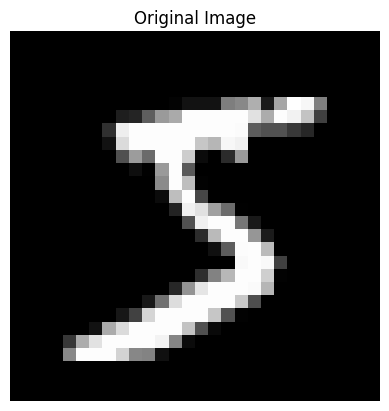

In [5]:
plt.imshow(x_train[0], cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [6]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [7]:
# Normalize pixel values to the range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add the channel dimension
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


In [8]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [9]:
# Set the amount of noise
noise_factor = 0.4

# Create noisy training images
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

# Create noisy testing images
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Keep pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

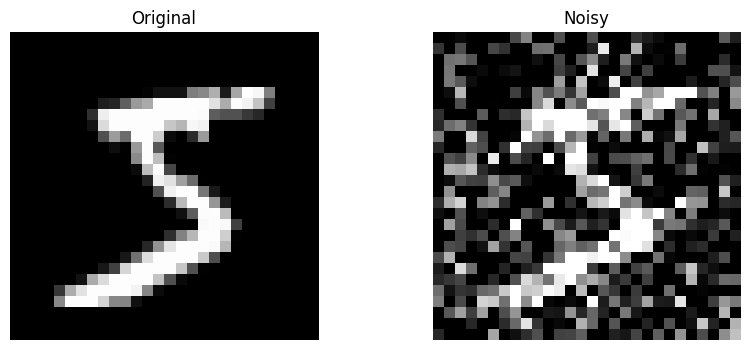

In [10]:
plt.figure(figsize=(10,4))

# Original Image
plt.subplot(1,2,1)
plt.imshow(x_train[0].squeeze(), cmap="gray")
plt.title("Original")
plt.axis("off")

# Noisy Image
plt.subplot(1,2,2)
plt.imshow(x_train_noisy[0].squeeze(), cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.show()

In [11]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

In [12]:
# Input Layer
input_img = Input(shape=(28, 28, 1))

# -------- Encoder --------
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# -------- Decoder --------
x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Create Model
autoencoder = Model(input_img, decoded)

In [13]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [14]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 121s 252ms/step - loss: 0.1735 - val_loss: 0.1064
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 249ms/step - loss: 0.1030 - val_loss: 0.0983
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 146s 258ms/step - loss: 0.0977 - val_loss: 0.0949
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 246ms/step - loss: 0.0950 - val_loss: 0.0930
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 241ms/step - loss: 0.0936 - val_loss: 0.0918
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 148s 254ms/step - loss: 0.0925 - val_loss: 0.0911
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 154s 280ms/step - loss: 0.0916 - val_loss: 0.0904
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 129s 274ms/step - loss: 0.0910 - val_loss: 0.0899
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 266ms/step - loss: 0.0904 - val_loss: 0.0892
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 260ms/step - loss: 0.0900 - val_loss: 0.0890


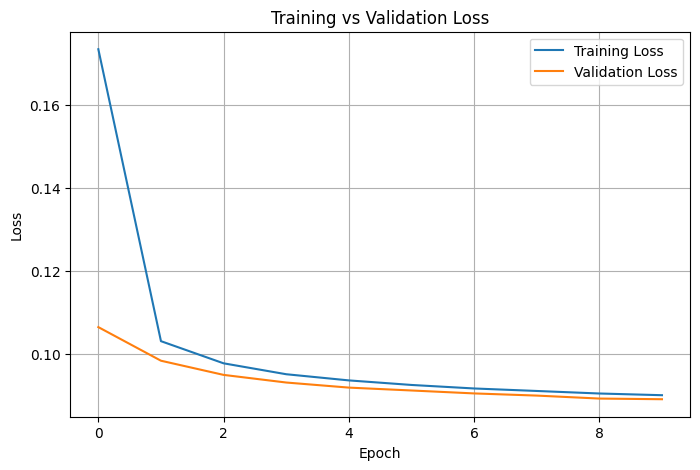

In [16]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Generate denoised images
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


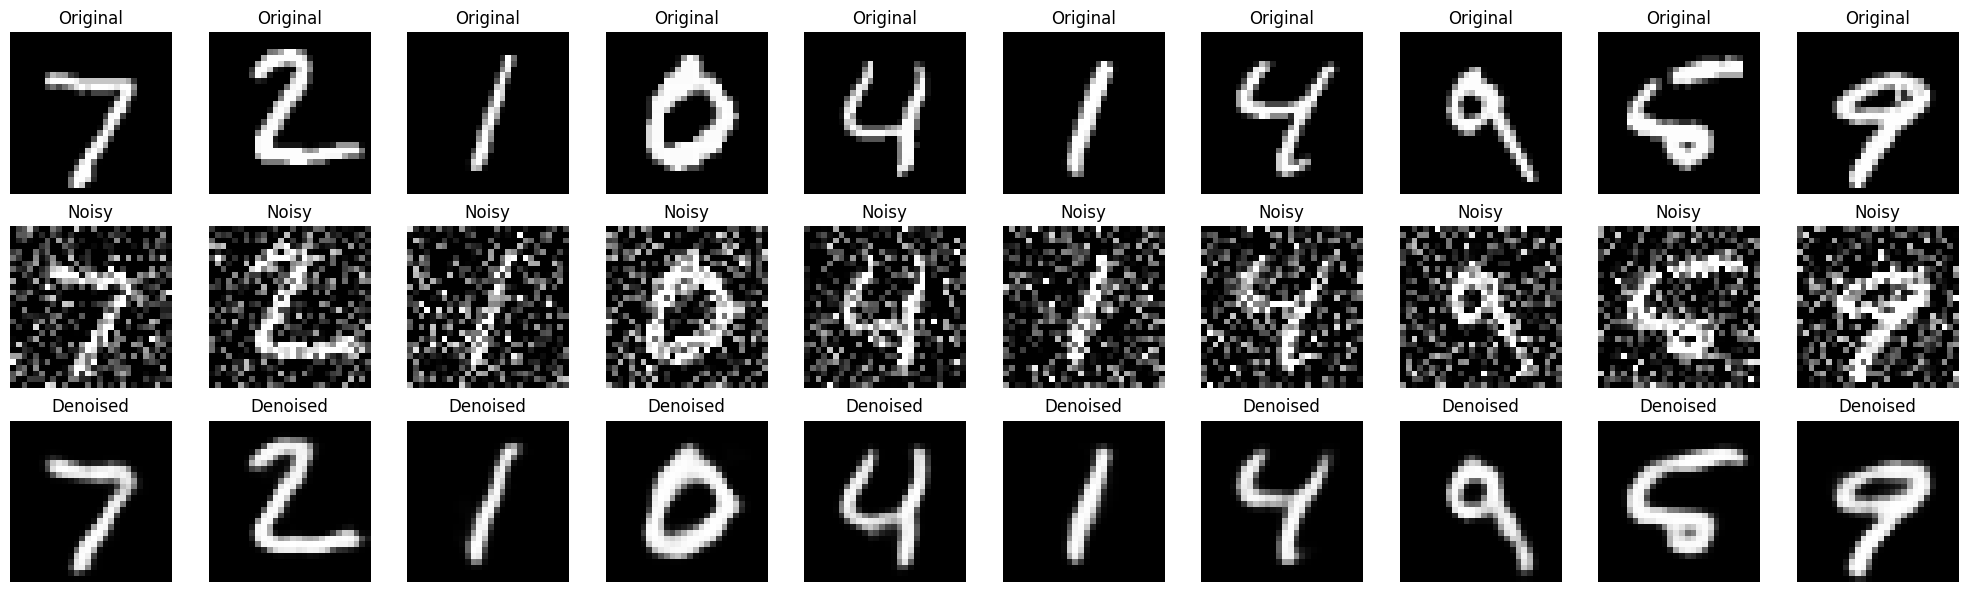

In [18]:
n = 10  # Number of images to display

plt.figure(figsize=(20, 6))

for i in range(n):

    # Original Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised Image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
autoencoder.save("mnist_denoising_autoencoder.keras")

In [20]:
autoencoder.save("mnist_denoising_autoencoder.h5")

In [21]:
from google.colab import files
files.download("mnist_denoising_autoencoder.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>